#Perceptrón

##Aprendizaje del modelo
##### ¿Cómo aprende el modelo? Tras cada ejemplo de entrada, se compara el valor predicho con el valor real. De esta forma, se cuantifica el error cometido mediante una función de costes (o función de pérdidas) 𝐽(ŷ(i), 𝑦(i)). Notemos que, dado un vector de entrada Representación gráfica vector variable(i), el valor predicho depende únicamente de los pesos. Por tanto, dado un ejemplo de entrenamiento (Representación gráfica vector variable(i), 𝑦(i)), la función de costes depende únicamente del vector de pesos, 𝐽 = 𝐽(Representación gráfica del vector de pesos).
##### Así, conociendo el gradiente de la función de costes respecto de los pesos ∇𝐽(Representación gráfica del vector de pesos), podemos usar el descenso del gradiente para ir actualizando los pesos a medida que hacemos predicciones. De esta forma, se minimizará la función de costes.
##### Existen distintas variantes del descenso del gradiente, que dependen de la frecuencia con la que se actualizan los pesos. En el descenso del gradiente estocástico, los pesos se actualizan tras cada ejemplo de entrenamiento. Por otro lado, en el descenso del gradiente en minibatch, se actualizan tras cierto número de ejemplos. Y, por último, en el descenso del gradiente en batch, la actualización se produce tras cada epoch o bucle sobre todo el conjunto de entrenamiento. Así, la actualización de los pesos Representación gráfica del vector de pesos(𝑘) en cada iteración 𝑘 viene dada por la fórmula:

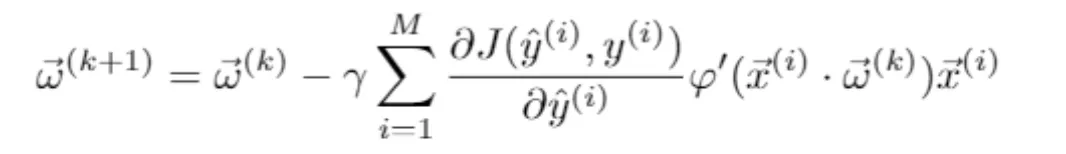

donde 𝛄 es el ratio de aprendizaje y el sumatorio recorre un número 𝑀 de ejemplos de entrenamiento, que depende de la modalidad del descenso del gradiente usada. Nótese que se ha usado la regla de la cadena para calcular el gradiente de la función de costes respecto al vector de pesos, ∇𝐽(Representación gráfica del vector de pesos(𝑘)), en función del valor predicho ŷ(i) = ŷ(i)(Representación gráfica del vector de pesos(𝑘)).

#CODE SECTION

## 1. Preparación de Datos y Visualización Inicial

Esta celda importa las librerías necesarias `numpy` para operaciones numéricas y `matplotlib.pyplot` para la visualización. Define un conjunto de datos `personas` que representa características (edad, ahorro) y `clases` que indica si a la persona se le aprobó (1) o denegó (0) una tarjeta Platinum. Finalmente, grafica estos datos, diferenciando las personas aprobadas y denegadas para una visualización inicial.

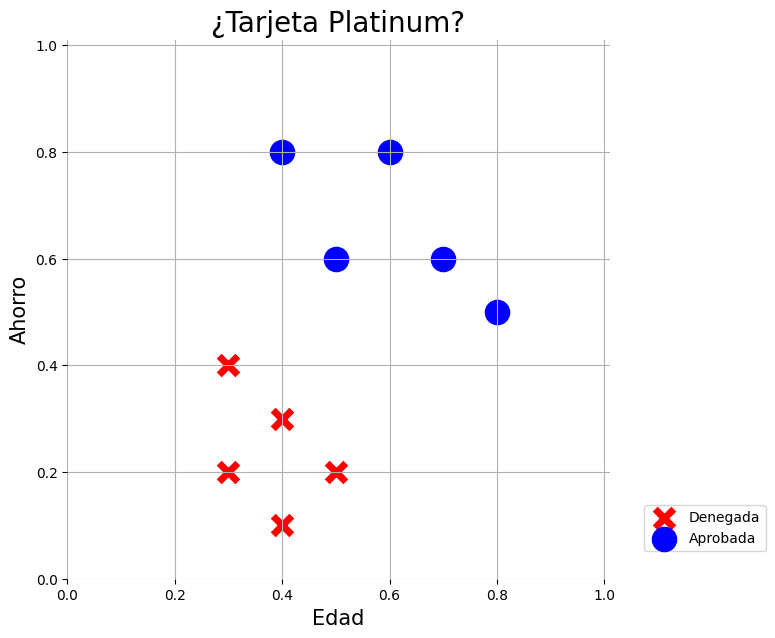

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de 10 personas -> [edad, ahorro]

personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1],
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6],
                     [0.7, 0.6], [0.8, 0.5]])

# 1 : aprobrada    0 : denegada

clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Gráfica de dispersión (edad, ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta Platinum?", fontsize=20)
plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

## 2. Función de Activación y Inicialización de Parámetros

Esta celda define la función de activación `activacion` que simula el comportamiento de una neurona perceptrón simple. Toma los `pesos`, las `x` (características de entrada) y el `b` (sesgo) para determinar la salida (1 o 0). También inicializa los `pesos` y el `b` con valores aleatorios para comenzar el entrenamiento del perceptrón, y luego realiza una primera prueba con valores de entrada para mostrar su funcionamiento inicial.

In [9]:
# w1*x1 + w2*x2 + ⋯ + wn*xn

def activacion(pesos, x, b):
    z = pesos * x
    if z.sum() + b > 0:
        return 1
    else:
        return 0

pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

pesos, b, activacion(pesos, [0.5, 0.4], b)

(array([ 0.48179743, -0.36668011]), 0.7169494710354947, 1)

## 3. Entrenamiento del Perceptrón

Esta celda implementa el algoritmo de entrenamiento del perceptrón. Inicializa los `pesos`, el `sesgo (b)`, la `tasa_de_aprendizaje` y el número de `épocas`. Luego, itera a través de las épocas, ajustando los pesos y el sesgo en cada paso para minimizar el error entre la predicción del perceptrón y la clase real. Al final de cada época, imprime el error total. Finalmente, se muestra la predicción para un nuevo conjunto de datos después del entrenamiento.

In [10]:
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
tasa_de_aprendizaje = 0.01
epocas = 100

for epoca in range(epocas):
    error_total = 0
    for i in range(len(personas)):
        prediccion = activacion(pesos, personas[i], b)
        error = clases[i] - prediccion
        error_total += error**2
        pesos[0] += tasa_de_aprendizaje * personas[i][0] * error
        pesos[1] += tasa_de_aprendizaje * personas[i][1] * error
        b += tasa_de_aprendizaje * error
    print(error_total, end=" ")

activacion(pesos, [0.5, 1], b)

5 4 4 4 4 5 5 5 4 5 4 3 2 4 3 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 3 2 2 1 2 2 2 1 2 2 2 1 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 

1

## 4. Visualización de la Frontera de Decisión del Perceptrón

Esta celda visualiza la frontera de decisión aprendida por el perceptrón. Recrea el gráfico de dispersión inicial de las personas aprobadas y denegadas. Adicionalmente, itera sobre un rango de valores para 'edad' y 'ahorro', y usa la función de `activacion` con los `pesos` y `b` entrenados para colorear el fondo del gráfico, mostrando así qué regiones el perceptrón clasificaría como 'aprobada' (azul) o 'denegada' (rojo).

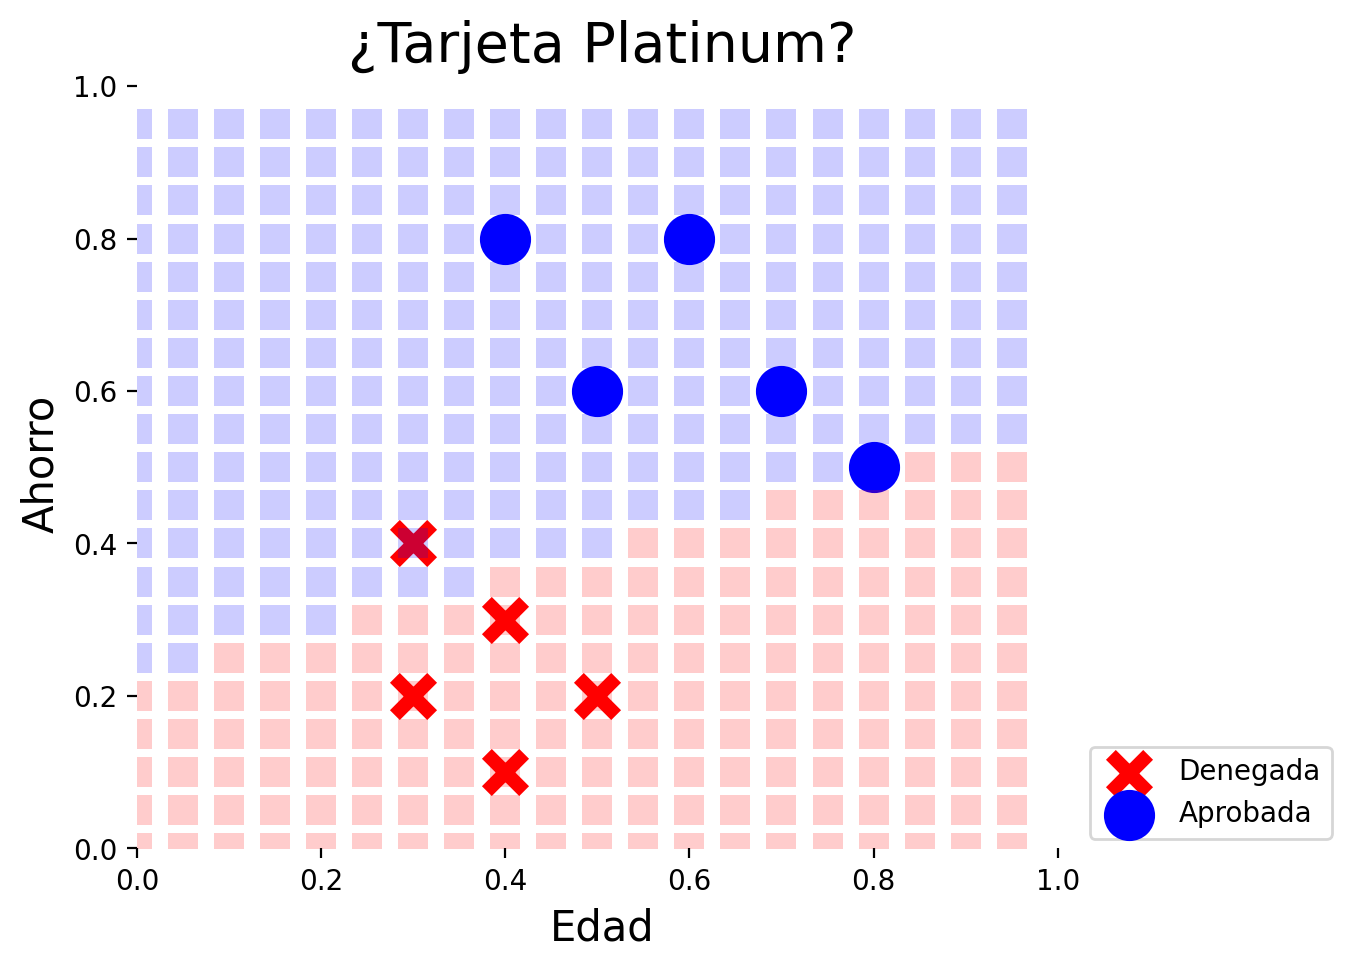

In [11]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activacion(pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="red", alpha=0.2, linewidths=0)

plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()

## 5. Perceptrón con Scikit-learn

Esta celda demuestra el uso del modelo Perceptrón de la librería `sklearn.linear_model`. Importa la clase `Perceptron`, entrena el modelo con los datos `personas` y `clases` existentes, y luego utiliza el modelo entrenado para realizar predicciones sobre nuevos datos de ejemplo.

In [12]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron().fit(personas, clases)
perceptron.predict([[0.2, 0.2], [0.8, 0.8]])

array([0, 1])

# "Joven haga su trabajo por favor"

###### 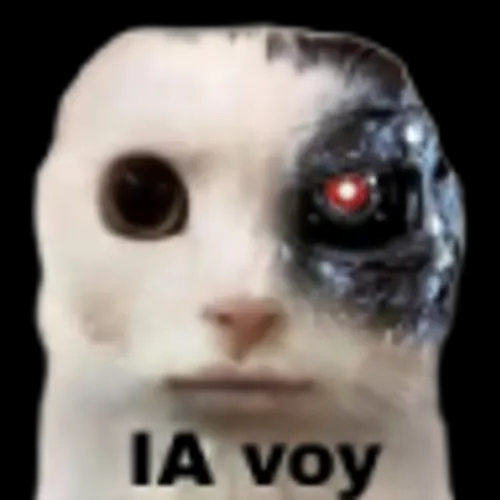

El chiste del gato que dice IA voy se refiere comunmente a utilizar inteligencia artificial para resolver los trabajos asignados de forma rapida.

La frase "Joven, haga su trabajo por favor" se suele usar seguido cuando un alumno no esta realizando trabajo en clase, por ello al utilizar la imagen del gato parcialmente robotico con la frase IA voy, se considera como un gesto comico.

*Explicacion generada por IA (Creanme)